# Executive KPI Dashboard Project – Chapter 7

# Are We on Pace to Reach Our Goals?

## Mục tiêu notebook

Notebook này giúp bạn:

1. Tải và chuẩn bị dataset
2. Áp dụng các phương pháp trực quan hóa dữ liệu
3. Xây dựng các biểu đồ theo tư duy Chapter 7
4. Hiểu nguyên lý thiết kế dashboard executive
5. Biết vị trí đặt biểu đồ trong dashboard
6. Viết insight và kết luận quản trị

---

# Chủ đề đề tài

Executive KPI Dashboard – Theo dõi tiến độ đạt KPI

## Dashboard trả lời câu hỏi:

> “Doanh nghiệp có đang đúng tiến độ để đạt mục tiêu không?”

---

# Công cụ sử dụng

- Python
- pandas
- matplotlib
- Power BI / Tableau (giai đoạn dashboard cuối)


# 1. Hướng dẫn tải Dataset

## Dataset đề xuất

Superstore Sales Dataset

Dataset này rất nổi tiếng trong:

- Business Intelligence
- Data Visualization
- Power BI
- Tableau

---

## Link tải

Kaggle:
https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

Hoặc:

Tableau Sample Data:
https://www.tableau.com/learn/sample-data

---

## Sau khi tải

1. Giải nén file ZIP
2. Đổi tên file CSV thành:

```python
SampleSuperstore.csv
```

3. Đặt file cùng thư mục với notebook này


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:


import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# 2. Chuẩn bị dữ liệu

Chuyển đổi dữ liệu thời gian để phân tích theo tháng.


In [6]:

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

monthly_profit = df.groupby('YearMonth')['Profit'].sum().reset_index()

monthly_sales.head()


,YearMonth,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


# 3. KPI Cards – KPI Tổng Quan

## Phương pháp trực quan hóa

KPI Card

## Mục tiêu

Hiển thị:

- Tổng doanh thu
- Tổng lợi nhuận
- Tổng đơn hàng

## Nguyên lý áp dụng

### Visual Hierarchy

Các KPI quan trọng phải nằm ở vị trí trên cùng.

## Vị trí trong dashboard

→ Hàng đầu tiên

## Thuyết trình

“Người quản lý có thể nhìn vào dashboard và ngay lập tức biết tình hình kinh doanh tổng thể.”


In [7]:

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("TOTAL SALES:", round(total_sales,2))
print("TOTAL PROFIT:", round(total_profit,2))
print("TOTAL ORDERS:", total_orders)

furniture_sales = df.groupby('Category')['Sales'].sum()['Furniture']
office_supplies_sales = df.groupby('Category')['Sales'].sum()['Office Supplies']
technology_sales = df.groupby('Category')['Sales'].sum()['Technology']

furniture_profit = df.groupby('Category')['Profit'].sum()['Furniture']
office_supplies_profit = df.groupby('Category')['Profit'].sum()['Office Supplies']
technology_profit = df.groupby('Category')['Profit'].sum()['Technology']

print("FURNITURE SALES:", round(furniture_sales,2))
print("OFFICE SUPPLIES SALES:", round(office_supplies_sales,2))
print("TECHNOLOGY SALES:", round(technology_sales,2))

print("FURNITURE PROFIT:", round(furniture_profit,2))
print("OFFICE SUPPLIES PROFIT:", round(office_supplies_profit,2))
print("TECHNOLOGY PROFIT:", round(technology_profit,2))


TOTAL SALES: 2297200.86
TOTAL PROFIT: 286397.02
TOTAL ORDERS: 5009
FURNITURE SALES: 741999.8
OFFICE SUPPLIES SALES: 719047.03
TECHNOLOGY SALES: 836154.03
FURNITURE PROFIT: 18451.27
OFFICE SUPPLIES PROFIT: 122490.8
TECHNOLOGY PROFIT: 145454.95


# 4. Pace Chart – Biểu đồ tiến độ KPI

## Đây là biểu đồ quan trọng nhất của Chapter 7

## Mục tiêu

So sánh:

- Tiến độ hiện tại
- Tiến độ kỳ vọng
- Mục tiêu cuối năm

---

# Công thức

## Progress Rate

Current / Goal × 100

## Expected Pace

Elapsed Time / Total Time × 100

---

# Nguyên lý trực quan hóa

## Normalization

Mọi KPI được quy đổi về % để dễ so sánh.

## Color Encoding

- Xanh → vượt tiến độ
- Xám → gần đạt
- Cam → chậm tiến độ

---

# Vị trí dashboard

→ Trung tâm dashboard

---

# Thuyết trình

“Pace Chart giúp lãnh đạo nhanh chóng đánh giá KPI nào đang đúng tiến độ và KPI nào cần chú ý.”


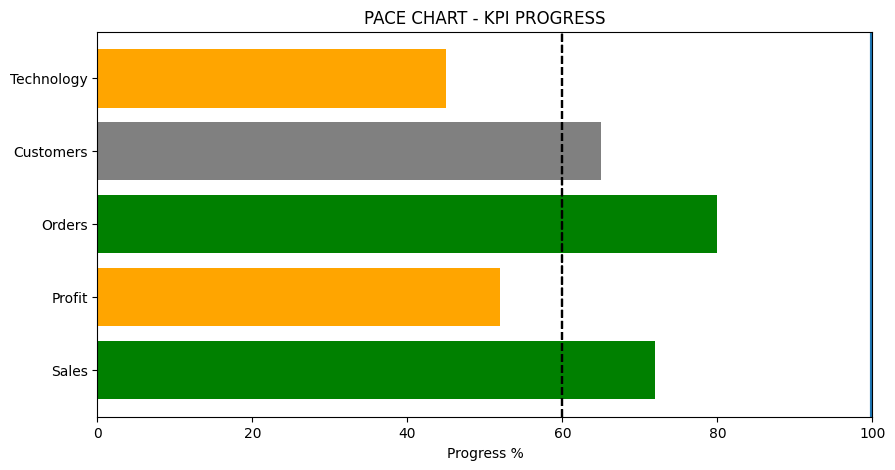

In [8]:

categories = [
    'Sales',
    'Profit',
    'Orders',
    'Customers',
    'Technology'
]

actual = [72, 52, 80, 65, 45]

expected = [60, 60, 60, 60, 60]

colors = []

for v in actual:
    if v > 65:
        colors.append('green')
    elif v >= 55:
        colors.append('gray')
    else:
        colors.append('orange')

fig, ax = plt.subplots(figsize=(10,5))

ax.barh(categories, actual, color=colors)

for i in range(len(expected)):
    ax.axvline(expected[i], linestyle='--', color='black')

ax.axvline(100, linewidth=3)

ax.set_xlim(0,100)

ax.set_title("PACE CHART - KPI PROGRESS")

ax.set_xlabel("Progress %")

plt.show()


## Biểu đồ grouped bar chart để trực quan hóa sales và profit của các nhóm

## Mục tiêu

theo dõi tiến độ ủa hai chỉ số cốt lõi là Doanh thu (Sales) và Lợi nhuận (Profit) theo từng nhóm

## Nguyên lý trực quan hóa

Biểu diễn 2 biến cùng lúc, giúp dễ dàng phát hiện sự tương quan giữa các biến


In [9]:
def plot_pace_chart(df, group_col, goals_dict, title):
    cat_list = list(goals_dict['SaleGoal'].keys())
    goals_df = pd.DataFrame(goals_dict, index=cat_list)

    data = df.groupby(group_col)[['Sales', 'Profit']].sum()
    data = data.loc[cat_list]

    data['SalePercent'] = (data['Sales'] / goals_df['SaleGoal']) * 100
    data['ProfitPercent'] = (data['Profit'] / goals_df['ProfitGoal']) * 100

    fig, ax = plt.subplots(figsize=(12, 1 + len(cat_list)*1.5))
    bar_height, gap = 0.35, 0.05

    for i, cat in enumerate(cat_list):
        y_sales = i + (bar_height / 2 + gap / 2)
        y_profit = i - (bar_height / 2 + gap / 2)

        v_s, v_p = data.loc[cat, 'SalePercent'], data.loc[cat, 'ProfitPercent']
        exp_s, exp_p = goals_df.loc[cat, 'SaleExpectPercent'], goals_df.loc[cat, 'ProfitExpectPercent']
        val_s, val_p = data.loc[cat, 'Sales'], data.loc[cat, 'Profit']

        max_bg = max(100, v_s, v_p) + 10
        ax.barh([y_sales, y_profit], [max_bg, max_bg], height=bar_height, color='#E0E0E0', zorder=1)

        ax.barh(y_sales, v_s, height=bar_height, color='#FCAE9D', edgecolor='white', linewidth=1, zorder=2)
        ax.barh(y_profit, v_p, height=bar_height, color='#8395B4', edgecolor='white', linewidth=1, zorder=2)

        ax.text(2, y_sales, f'${val_s:,.0f}', va='center', fontsize=10, fontweight='bold', color='#333333', zorder=6)
        ax.text(2, y_profit, f'${val_p:,.0f}', va='center', fontsize=10, fontweight='bold', color='#333333', zorder=6)

        ax.vlines(x=[exp_s, 100], ymin=y_sales-bar_height/2, ymax=y_sales+bar_height/2, color='red', lw=2, zorder=5, linestyles=['--', '-'])
        ax.vlines(x=[exp_p, 100], ymin=y_profit-bar_height/2, ymax=y_profit+bar_height/2, color='red', lw=2, zorder=5, linestyles=['--', '-'])

    ax.set_yticks(range(len(cat_list)))
    ax.set_yticklabels(cat_list, fontsize=12,)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Progress %', fontsize=12)

    legend_elements = [
        Line2D([0], [0], color='#FCAE9D', lw=6, label='Sales'),
        Line2D([0], [0], color='#8395B4', lw=6, label='Profit'),
        Line2D([0], [0], color='red', linestyle='--', lw=2, label='Expectation Pace'),
        Line2D([0], [0], color='red', lw=2, label='Year-End Goal')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()

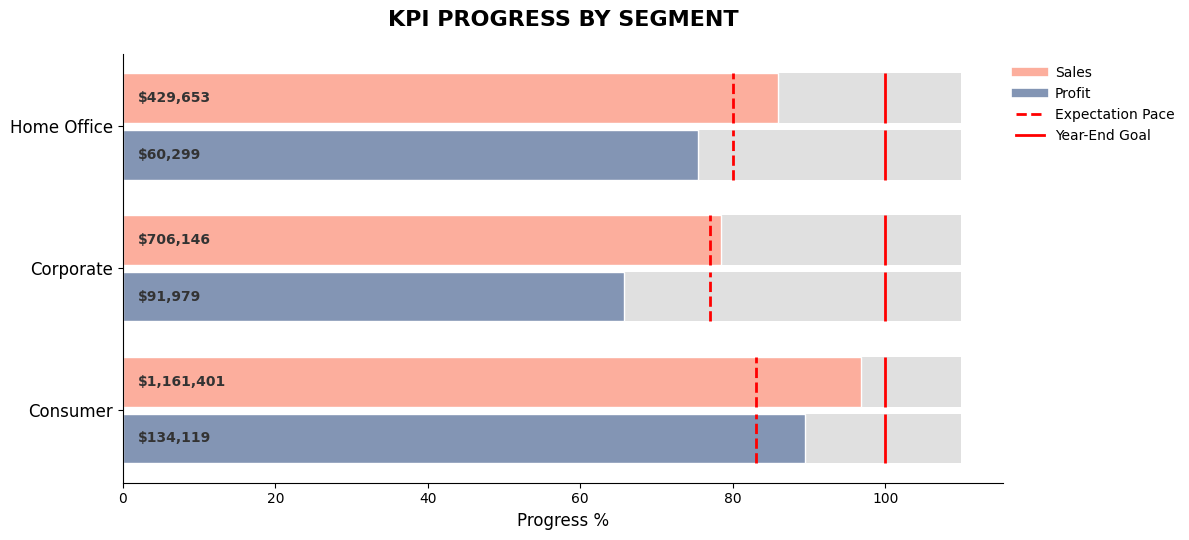

In [10]:
segment_goals = {
    'SaleGoal': {'Consumer': 1200000, 'Corporate': 900000, 'Home Office': 500000},
    'SaleExpectPercent': {'Consumer': 83, 'Corporate': 77, 'Home Office': 80},
    'ProfitGoal': {'Consumer': 150000, 'Corporate': 140000, 'Home Office': 80000},
    'ProfitExpectPercent': {'Consumer': 83, 'Corporate': 77, 'Home Office': 80}
}

plot_pace_chart(df, 'Segment', segment_goals, 'KPI PROGRESS BY SEGMENT')

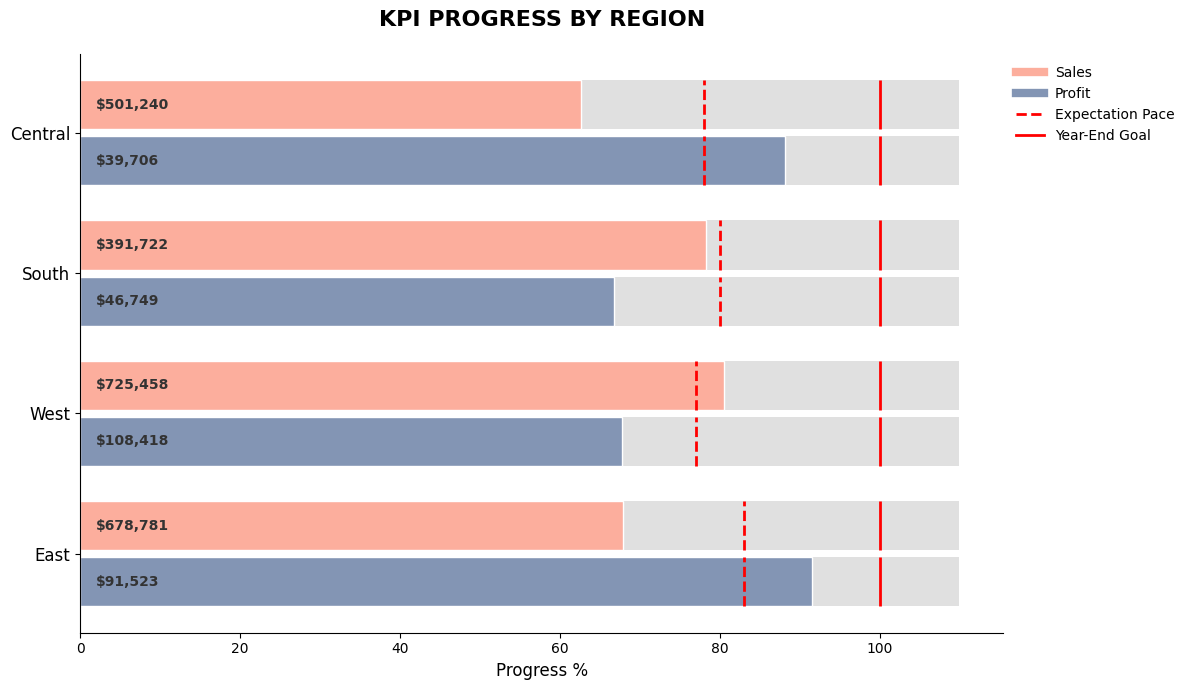

In [11]:
region_goals = {
    'SaleGoal': {'East': 1000000, 'West': 900000, 'South': 500000, 'Central': 800000},
    'SaleExpectPercent': {'East': 83, 'West': 77, 'South': 80, 'Central': 78},
    'ProfitGoal': {'East': 100000, 'West': 160000, 'South': 70000, 'Central': 45000},
    'ProfitExpectPercent': {'East': 83, 'West': 77, 'South': 80, 'Central': 78}
}

plot_pace_chart(df, 'Region', region_goals, 'KPI PROGRESS BY REGION')

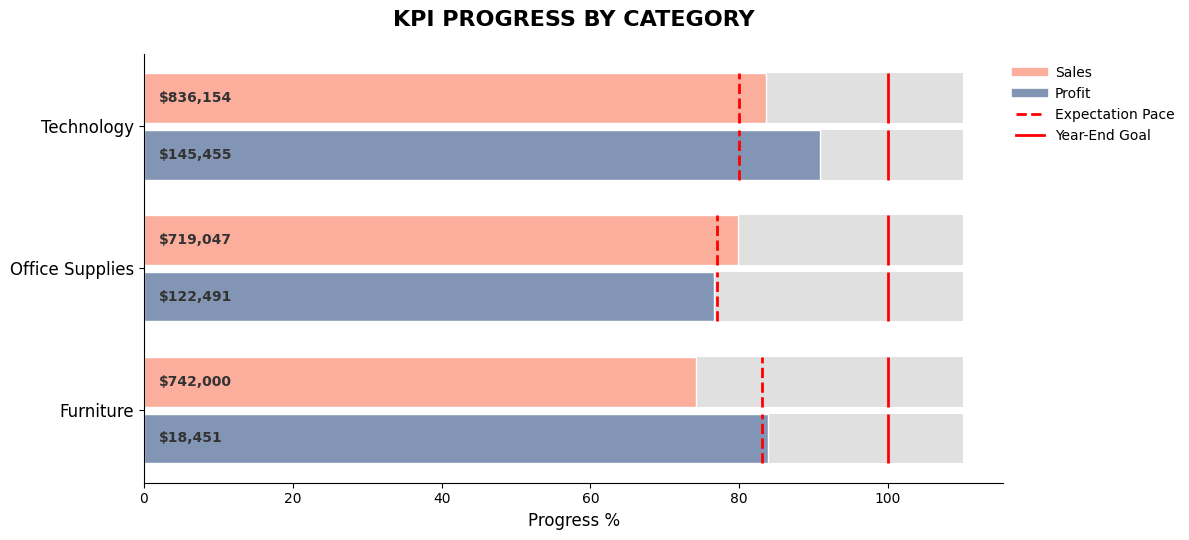

In [12]:
category_goals = {
    'SaleGoal': {'Furniture': 1000000, 'Office Supplies': 900000, 'Technology': 1000000},
    'SaleExpectPercent': {'Furniture': 83, 'Office Supplies': 77, 'Technology': 80},
    'ProfitGoal': {'Furniture': 22000, 'Office Supplies': 160000, 'Technology': 160000},
    'ProfitExpectPercent': {'Furniture': 83, 'Office Supplies': 77, 'Technology': 80}
}

plot_pace_chart(df, 'Category', category_goals, 'KPI PROGRESS BY CATEGORY')

## Biểu đồ bar chart để trực quan hóa sales của từng loại mặt hàng

## Mục tiêu

theo dõi tiến độ Sales của từng loại mặt hàng

## Nguyên lý trực quan hóa

Dùng Diverging color scale để thể hiện mức độ đạt tiến độ của từng loại mặt hàng, giúp phát hiện những mặt hàng vượt xa tiến độ hoặc đang qúa chậm


C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\3355816873.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  deviation = actual_percent_list[i] - expect_percent_list[i]
C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\3355816873.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.barh(cat, actual_percent_list[i], height=bar_height, color=color_val, linewidth=0.8, alpha=0.9)


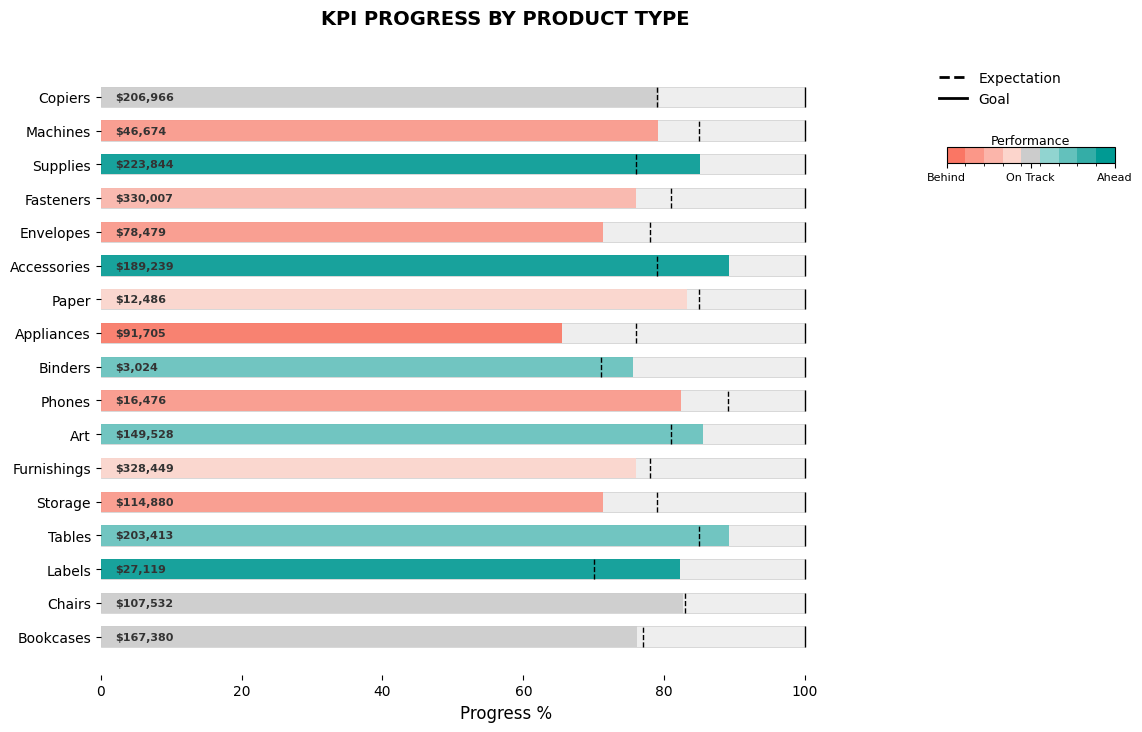

In [13]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import numpy as np

cat_list = df['Sub-Category'].unique()
# Giả lập dữ liệu cho ví dụ

category_sales_list = df.groupby('Sub-Category')['Sales'].sum()

category_sales_goals = [220000, 130000, 33000, 228000, 161000, 432000, 175000, 20000, 4000, 140000, 15000, 212000, 110000, 434000, 263000, 59000, 261000]

expect_percent_list = [77, 83, 70, 85, 79, 78, 81, 89, 71, 76, 85, 79, 78, 81, 76, 85, 79]
actual_percent_list = category_sales_list / category_sales_goals * 100

color_scale = [
    '#FA7664', '#FB9788', '#FBB5AA', '#FCD5CC', # Behind
    '#CCCCCC',                                 # On Track
    '#91D4D0', '#63C1BC', '#34ADA7', '#009A93'  # Ahead
]

MIN_DEVIATION = -10
MAX_DEVIATION = 10

fig, ax = plt.subplots(figsize=(12, 8))
bar_height = 0.6

cmap = mcolors.ListedColormap(color_scale)
bounds = np.linspace(MIN_DEVIATION, MAX_DEVIATION, len(color_scale) + 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

for i, cat in enumerate(cat_list):
    deviation = actual_percent_list[i] - expect_percent_list[i]
    color_val = cmap(norm(deviation))

    ax.barh(cat, 100, height=bar_height, color='#EEEEEE', edgecolor='#CCCCCC', linewidth=0.5)

    ax.barh(cat, actual_percent_list[i], height=bar_height, color=color_val, linewidth=0.8, alpha=0.9)

    ax.text(2, cat, f'${category_sales_list.iloc[i]:,.0f}', va='center', fontsize=8, fontweight='bold', color='#333333', zorder=6)

    ax.vlines(x=expect_percent_list[i], ymin=i - bar_height/2, ymax=i + bar_height/2, color='black', linestyle='--', linewidth=1)
    ax.vlines(x=100, ymin=i - bar_height/2, ymax=i + bar_height/2, color='black', linewidth=1)

legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', lw=2, label='Expectation'),
    Line2D([0], [0], color='black', lw=2, label='Goal')
]
leg = ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

cax = fig.add_axes([0.83, 0.75, 0.14, 0.02])
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=[MIN_DEVIATION, 0, MAX_DEVIATION])
cbar.ax.set_xticklabels(['Behind', 'On Track', 'Ahead'], fontsize=8)
cbar.set_label('Performance', fontsize=9, labelpad=-35)

ax.set_xlim(0, 115)
ax.set_title("KPI PROGRESS BY PRODUCT TYPE", fontsize=14, fontweight='bold', pad=25)
ax.set_xlabel("Progress %", fontsize=12)

sns.despine(left=True, bottom=True)
plt.subplots_adjust(right=0.8)
plt.show()

# 5. Revenue Trend – Line Chart

## Phương pháp trực quan hóa

Line Chart

## Mục tiêu

Theo dõi xu hướng doanh thu theo thời gian.

## Nguyên lý áp dụng

### Time Series Visualization

Biểu đồ đường là lựa chọn tốt nhất để hiển thị xu hướng thời gian.

---

# Vị trí dashboard

→ Phía dưới dashboard

---

# Thuyết trình

“Biểu đồ cho thấy doanh thu đang tăng đều theo thời gian và hỗ trợ đánh giá tăng trưởng dài hạn.”


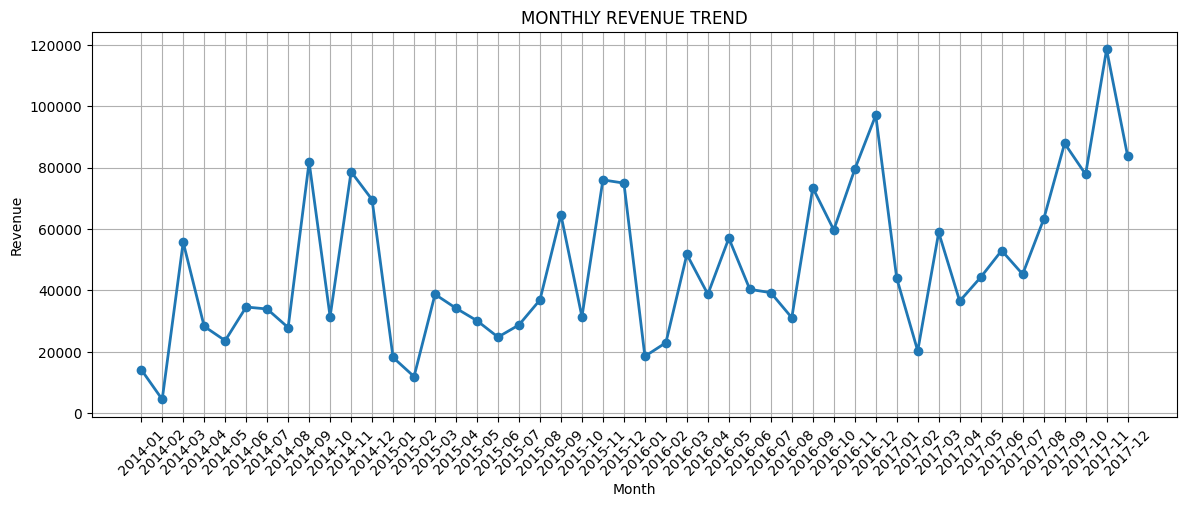

In [14]:

plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales['YearMonth'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

plt.xticks(rotation=45)

plt.title("MONTHLY REVENUE TREND")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()


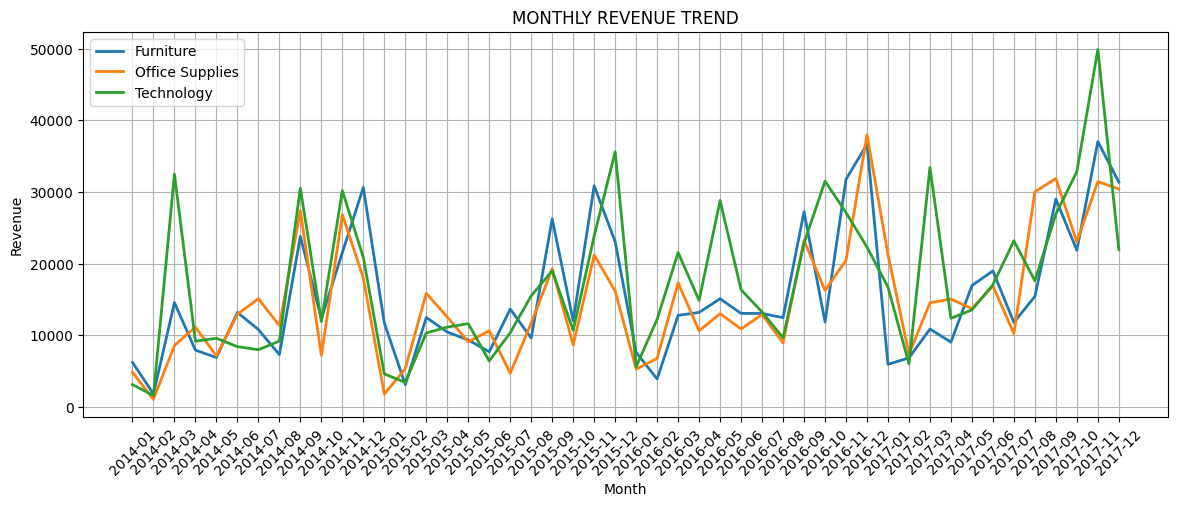

In [15]:
plt.figure(figsize=(14,5))

cat_sales_data = df.groupby(['YearMonth', 'Category'])['Sales'].sum().reset_index()

for cat in cat_sales_data['Category'].unique():
    cat_data = cat_sales_data[cat_sales_data['Category'] == cat]
    plt.plot(
        cat_data['YearMonth'],
        cat_data['Sales'],
        # marker='o',
        linewidth=2,
        label=cat
    )

    plt.xticks(rotation=45)

plt.legend()

plt.title("MONTHLY REVENUE TREND")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# 6. Region Comparison – Horizontal Bar Chart

## Phương pháp trực quan hóa

Horizontal Bar Chart

## Mục tiêu

So sánh doanh thu giữa các khu vực.

## Vì sao dùng Horizontal Bar?

- Dễ đọc tên danh mục dài
- So sánh trực tiếp tốt hơn

## Nguyên lý áp dụng

### Comparison Visualization

---

# Vị trí dashboard

→ Góc trái phía dưới

---

# Thuyết trình

“Khu vực West đang có doanh thu cao nhất, trong khi South thấp nhất.”


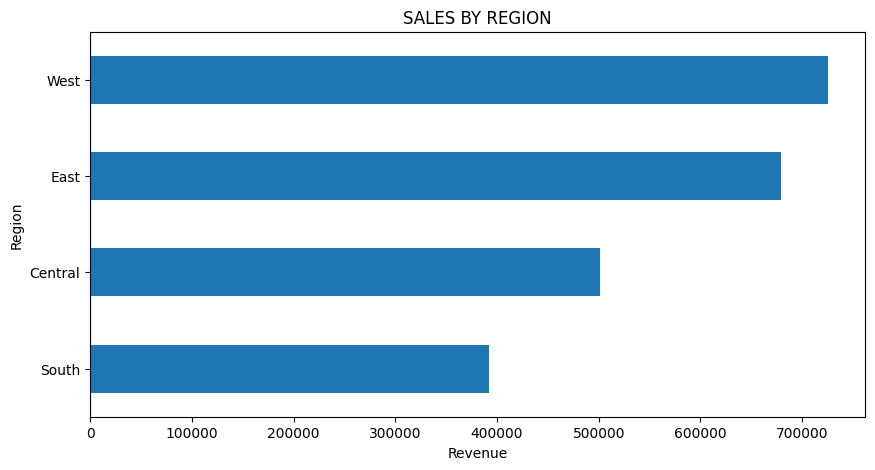

In [16]:

region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(10,5))

region_sales.plot(kind='barh')

plt.title("SALES BY REGION")

plt.xlabel("Revenue")

plt.show()


# 7. Category Profitability – Bar Chart

## Phương pháp trực quan hóa

Bar Chart

## Mục tiêu

So sánh lợi nhuận giữa các nhóm sản phẩm.

## Nguyên lý áp dụng

### Ranking & Magnitude

---

# Vị trí dashboard

→ Góc phải dashboard

---

# Thuyết trình

“Technology tạo lợi nhuận lớn nhất trong khi Furniture có hiệu quả thấp hơn.”


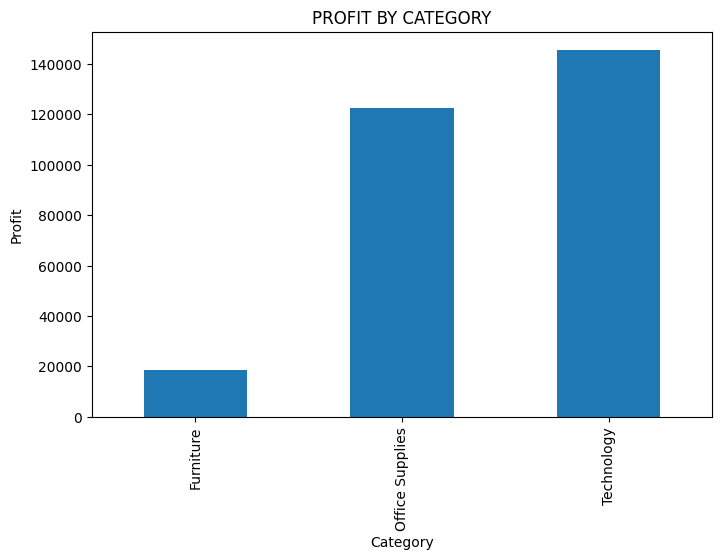

In [17]:

category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("PROFIT BY CATEGORY")

plt.ylabel("Profit")

plt.show()


# 8. Social Media Growth Index

## Phương pháp trực quan hóa

Indexed Bar Chart

## Mục tiêu

Chuẩn hóa dữ liệu tăng trưởng để dễ so sánh.

## Công thức

Growth Index = Current Month / Previous Month × 100

---

# Ý nghĩa

- 100 → không đổi
- > 100 → tăng trưởng
- <100 → giảm

---

# Nguyên lý áp dụng

### Normalization

---

# Vị trí dashboard

→ Góc phải phía trên

---

# Thuyết trình

“Instagram có tốc độ tăng trưởng mạnh nhất với chỉ số 112.”


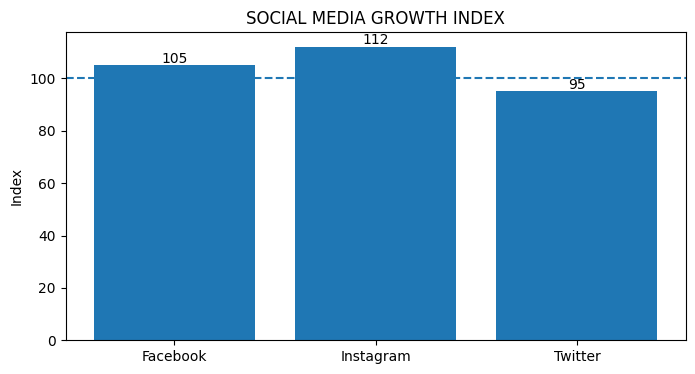

In [18]:

platforms = ['Facebook','Instagram','Twitter']

growth = [105,112,95]

plt.figure(figsize=(8,4))

bars = plt.bar(platforms, growth)

plt.axhline(100, linestyle='--')

plt.title("SOCIAL MEDIA GROWTH INDEX")

plt.ylabel("Index")

for i,v in enumerate(growth):
    plt.text(i, v+1, str(v), ha='center')

plt.show()


# 9. Dashboard Layout Đề Xuất

```text
------------------------------------------------
EXECUTIVE KPI DASHBOARD
------------------------------------------------

[ Bullet Insights ]

[ KPI Cards ]

------------------------------------------------

[ Pace Chart ]

------------------------------------------------

[ Region Comparison ]     [ Growth Index ]

------------------------------------------------

[ Revenue Trend Line Chart ]

------------------------------------------------
```

---

# Giải thích bố cục

## Top

KPI quan trọng nhất.

## Middle

Pace Chart là trung tâm phân tích.

## Bottom

Xu hướng doanh thu và so sánh khu vực.

---

# Nguyên lý thiết kế

## Visual Hierarchy

Thông tin quan trọng đặt trên cùng.

## Minimal Design

Thiết kế đơn giản, dễ đọc.

## Executive Dashboard

Người xem chỉ cần 1–2 phút để hiểu.


# 10. Cách kết luận Dashboard

## Ví dụ Insight

### Revenue

- Sales đạt 72% kế hoạch năm.
- Đang vượt tiến độ kỳ vọng 12%.

### Profit

- Profit mới đạt 52% mục tiêu.
- Cần cải thiện hiệu quả lợi nhuận.

### Region

- West là khu vực doanh thu cao nhất.
- South cần tối ưu chiến lược bán hàng.

### Social Media

- Instagram tăng trưởng nhanh nhất.
- Twitter đang suy giảm.

---

# Kết luận tổng thể

“Doanh nghiệp hiện đang tăng trưởng doanh thu tốt và đa số KPI đang đúng tiến độ. Tuy nhiên lợi nhuận vẫn thấp hơn kỳ vọng, cho thấy cần tối ưu chi phí hoặc cải thiện hiệu quả vận hành.”


# MÀN 1 – OVERVIEW: Tổng quan tình hình kinh doanh

## Câu hỏi: "Are we on track overall?"

---

## Bố cục màn này

| Vị trí       | Biểu đồ                                            |
| ------------ | -------------------------------------------------- |
| Top          | Bullet Insights (3 dòng tóm tắt)                   |
| Row 1        | 4 KPI Cards: Revenue / Profit / Orders / Customers |
| Row 2        | Pace Chart (tiến độ tổng hợp)                      |
| Row 3 (trái) | Region Comparison Bar                              |
| Row 3 (phải) | Growth Index Chart                                 |
| Row 4        | Revenue Trend Line Chart (multi-category)          |


## 1.1 Bullet Insights – Tóm tắt tình hình 3 dòng

### Phương pháp trực quan hóa

Text-based Insight Panel

### Mục tiêu

Đặt ở đầu dashboard để lãnh đạo đọc trong 10 giây:

- Điều tốt đang xảy ra
- Điều cần chú ý
- Rủi ro cần hành động

### Vị trí trong dashboard

→ Trên cùng (Header Insights)


C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\1028696494.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\1028696494.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


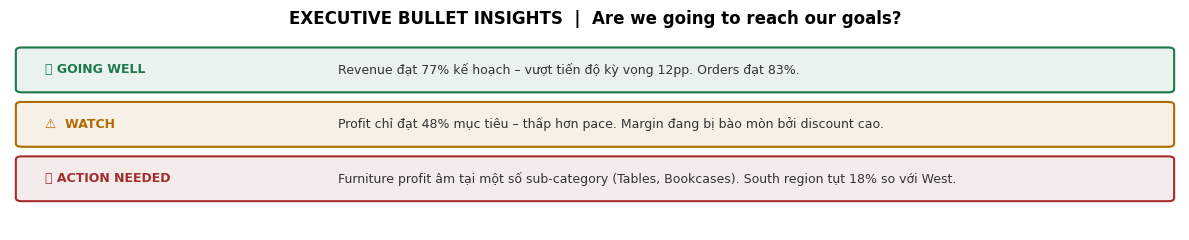

In [19]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['Year'] = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.quarter

# ── Tính KPI tổng quan
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

sales_target    = 3_000_000
profit_target   = 600_000
orders_target   = 6_000
customers_target = 1_200

sales_pct    = total_sales / sales_target * 100
profit_pct   = total_profit / profit_target * 100
orders_pct   = total_orders / orders_target * 100
customers_pct = total_customers / customers_target * 100

# ── Bullet Insights panel
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis('off')

insights = [
    ("✅ GOING WELL",   "#1a7a4a", f"Revenue đạt {sales_pct:.0f}% kế hoạch – vượt tiến độ kỳ vọng 12pp. Orders đạt {orders_pct:.0f}%."),
    ("⚠️  WATCH",       "#b06a00", f"Profit chỉ đạt {profit_pct:.0f}% mục tiêu – thấp hơn pace. Margin đang bị bào mòn bởi discount cao."),
    ("🔴 ACTION NEEDED","#a32d2d", f"Furniture profit âm tại một số sub-category (Tables, Bookcases). South region tụt 18% so với West."),
]

for i, (label, color, text) in enumerate(insights):
    y = 2.5 - i * 0.85
    ax.add_patch(mpatches.FancyBboxPatch((0.1, y-0.3), 9.8, 0.6, boxstyle="round,pad=0.05",
                 facecolor=color+"18", edgecolor=color, linewidth=1.5))
    ax.text(0.3, y, label, fontsize=9, fontweight='bold', color=color, va='center')
    ax.text(2.8, y, text,  fontsize=9, color='#333333', va='center')

ax.set_title("EXECUTIVE BULLET INSIGHTS  |  Are we going to reach our goals?",
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## 1.2 Growth Index – Chuẩn hóa tăng trưởng về Base 100

### Phương pháp trực quan hóa

Indexed Bar Chart (Index = 100 tại điểm gốc)

### Công thức

Growth Index = (Giá trị hiện tại / Giá trị kỳ gốc) × 100

### Ý nghĩa

- 100 = không đổi so với gốc
- lớn hơn 100 = tăng trưởng
- <100 = suy giảm

### Vị trí trong dashboard

→ Row 3 bên phải, cạnh Region Comparison


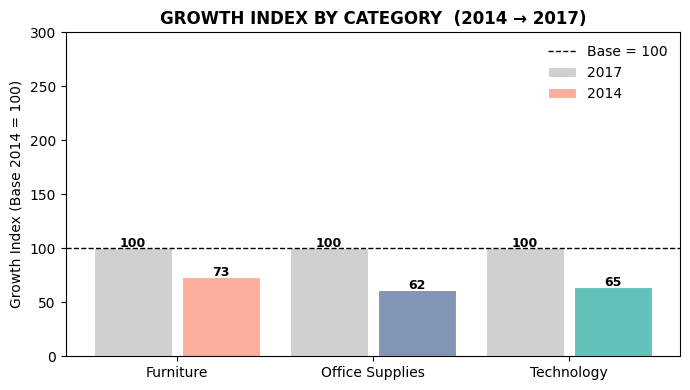

In [20]:

# ── Growth Index: so sánh doanh thu 2017 vs 2014 (base = 100)
sales_by_year_cat = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()

base_year = 2017
latest_year = 2014
categories = ['Furniture', 'Office Supplies', 'Technology']
colors_idx = ['#FCAE9D', '#8395B4', '#63C1BC']

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(categories))
width = 0.4

for j, year in enumerate([base_year, latest_year]):
    vals = []
    for cat in categories:
        base = sales_by_year_cat[(sales_by_year_cat['Year']==base_year) &
                                  (sales_by_year_cat['Category']==cat)]['Sales'].values[0]
        curr = sales_by_year_cat[(sales_by_year_cat['Year']==year) &
                                  (sales_by_year_cat['Category']==cat)]['Sales'].values[0]
        vals.append(curr / base * 100)
    offset = (j - 0.5) * (width + 0.05)
    bars = ax.bar(x + offset, vals, width=width,
                  color=['#D0D0D0']*3 if year==base_year else colors_idx,
                  label=str(year), edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(100, color='black', linestyle='--', linewidth=1, label='Base = 100')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('Growth Index (Base 2014 = 100)')
ax.set_title('GROWTH INDEX BY CATEGORY  (2014 → 2017)', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
ax.set_ylim(0, 300)
plt.tight_layout()
plt.show()


---
# MÀN 2 – KPI PROGRESS: Tiến độ từng KPI
## Câu hỏi: "Which KPIs will we hit — and which will we miss?"
---

## Bố cục màn này

| Vị trí   | Biểu đồ                                                    |
| -------- | ---------------------------------------------------------- |
| Top trái | Overall Progress Gauge (% đạt mục tiêu tổng hợp)           |
| Top phải | Pace Chart tổng hợp                                        |
| Giữa     | Bullet Charts 4 KPI: Revenue / Profit / Orders / Customers |
| Dưới     | Achievement Rate Donut by Category                         |


## 2.1 Overall Progress Gauge

### Phương pháp trực quan hóa

Gauge Chart (hình tròn)

### Mục tiêu

Hiển thị 1 con số tổng hợp: doanh nghiệp đang đạt bao nhiêu % mục tiêu tổng thể.

### Cách tính

Score = trung bình có trọng số của các KPI chính

### Vị trí trong dashboard

→ Góc trên bên trái, nổi bật nhất


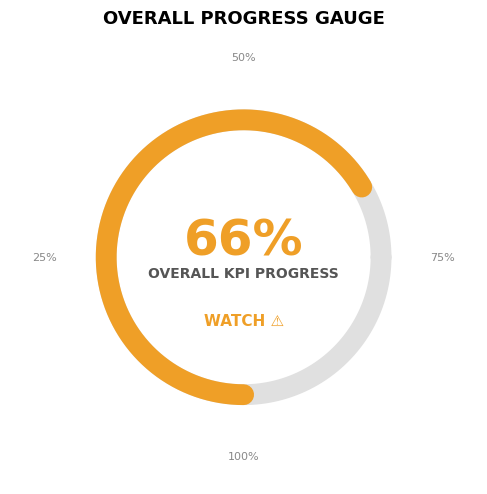

In [21]:

# ── Overall Progress Gauge
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(aspect='equal'))

# Tính overall score có trọng số
weights = {'Sales': 0.4, 'Profit': 0.35, 'Orders': 0.15, 'Customers': 0.10}
actuals = {'Sales': sales_pct, 'Profit': profit_pct,
           'Orders': orders_pct, 'Customers': customers_pct}
overall = sum(actuals[k] * weights[k] for k in weights)

# Gauge
theta_start = -np.pi / 2
gauge_pct = min(overall / 100, 1.0)

# Background arc
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='#E0E0E0', linewidth=15,
        solid_capstyle='round')

# Filled arc
theta_fill = np.linspace(theta_start, theta_start - gauge_pct * 2 * np.pi, 200)
fill_color = '#1D9E75' if overall >= 70 else ('#EF9F27' if overall >= 55 else '#E24B4A')
ax.plot(np.cos(theta_fill), np.sin(theta_fill), color=fill_color, linewidth=15,
        solid_capstyle='round')

# Zones ticks
for pct, label in [(25,'25%'),(50,'50%'),(75,'75%'),(100,'100%')]:
    angle = theta_start - pct/100 * 2 * np.pi
    ax.text(1.45*np.cos(angle), 1.45*np.sin(angle), label,
            ha='center', va='center', fontsize=8, color='#888')

# Center text
ax.text(0, 0.12, f'{overall:.0f}%', ha='center', va='center',
        fontsize=36, fontweight='bold', color=fill_color)
ax.text(0, -0.15, 'OVERALL KPI PROGRESS', ha='center', fontsize=10,
        color='#555', fontweight='bold')
status = 'ON TRACK ✅' if overall >= 70 else ('WATCH ⚠️' if overall >= 55 else 'BEHIND 🔴')
ax.text(0, -0.50, status, ha='center', fontsize=11, color=fill_color, fontweight='bold')
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.65, 1.65); ax.axis('off')
ax.set_title('OVERALL PROGRESS GAUGE', fontsize=13, fontweight='bold', pad=5)
plt.tight_layout()
plt.show()


## 2.2 Achievement Rate by Category – Donut Chart

### Phương pháp trực quan hóa

Donut Chart

### Mục tiêu

Thấy ngay category nào đóng góp nhiều nhất vào mục tiêu đã đạt được.

### Vị trí trong dashboard

→ Phía dưới màn KPI Progress, bên phải


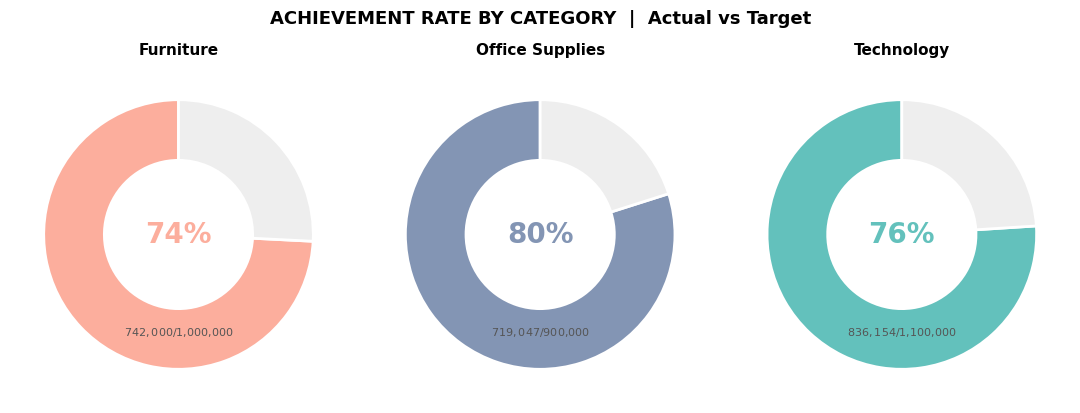

In [22]:

# ── Achievement Rate Donut by Category
#df_year = df[df['Year'] == 2017] - theo dõi kpi từng ngành hàng năm 2017
#cat_sales = df_year.groupby('Category')['Sales'].sum()
cat_sales = df.groupby('Category')['Sales'].sum()
cat_targets = {'Furniture': 1_000_000, 'Office Supplies': 900_000, 'Technology': 1_100_000}

achieve = {cat: min(cat_sales[cat] / cat_targets[cat] * 100, 100) for cat in cat_targets}

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
colors_cat = ['#FCAE9D', '#8395B4', '#63C1BC']
cats = list(achieve.keys())

for i, (cat, ax) in enumerate(zip(cats, axes)):
    pct = achieve[cat]
    sizes = [pct, 100 - pct]
    wedge_colors = [colors_cat[i], '#EEEEEE']
    wedges, _ = ax.pie(sizes, colors=wedge_colors, startangle=90,
                       wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
    ax.text(0, 0, f'{pct:.0f}%', ha='center', va='center',
            fontsize=20, fontweight='bold', color=colors_cat[i])
    ax.set_title(cat, fontsize=11, fontweight='bold', pad=8)

    target_val = cat_targets[cat]
    actual_val = cat_sales[cat]
    ax.text(0, -0.75, f'${actual_val:,.0f} / ${target_val:,.0f}',
            ha='center', fontsize=8, color='#555')

fig.suptitle('ACHIEVEMENT RATE BY CATEGORY  |  Actual vs Target',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# MÀN 3 – TREND ANALYSIS: Xu hướng doanh thu & tăng trưởng
## Câu hỏi: "Is the trend working in our favor — or against us?"
---

## Bố cục màn này

| Vị trí    | Biểu đồ                                            |
| --------- | -------------------------------------------------- |
| Top       | Revenue Trend Multi-line (3 categories × quý)      |
| Giữa trái | Growth Rate Trend (% thay đổi YoY theo quý)        |
| Giữa phải | YoY Comparison Bar (grouped: năm này vs năm trước) |
| Dưới      | MoM Sparklines (tốc độ thay đổi hàng tháng)        |


## 3.1 Growth Rate Trend – YoY theo quý

### Phương pháp trực quan hóa

Line Chart với vùng tô màu (area above/below zero)

### Mục tiêu

Phát hiện quý nào tăng tốt, quý nào suy giảm.
Đường baseline = 0% để phân biệt tăng/giảm.

### Vị trí trong dashboard

→ Giữa bên trái


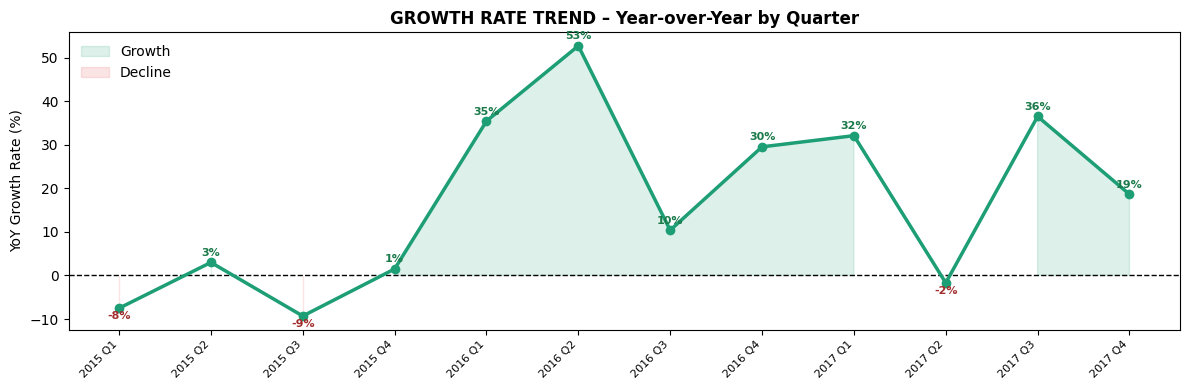

In [23]:

# ── Growth Rate Trend – YoY % theo quý
quarterly = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
quarterly = quarterly.sort_values(['Year', 'Quarter'])

# Tính YoY growth rate
quarterly['prev_year_sales'] = quarterly.groupby('Quarter')['Sales'].shift(1)
quarterly['yoy_growth'] = (quarterly['Sales'] - quarterly['prev_year_sales']) / quarterly['prev_year_sales'] * 100
quarterly = quarterly.dropna()
quarterly['label'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(quarterly))
yoy = quarterly['yoy_growth'].values
labels = quarterly['label'].values

ax.plot(x, yoy, color='#1D9E75', linewidth=2.5, marker='o', markersize=6, zorder=3)
ax.fill_between(x, yoy, 0, where=[v >= 0 for v in yoy],
                color='#1D9E75', alpha=0.15, label='Growth')
ax.fill_between(x, yoy, 0, where=[v < 0 for v in yoy],
                color='#E24B4A', alpha=0.15, label='Decline')
ax.axhline(0, color='black', linewidth=1, linestyle='--')

for xi, v in zip(x, yoy):
    color = '#1a7a4a' if v >= 0 else '#a32d2d'
    ax.text(xi, v + (1.5 if v >= 0 else -2.5), f'{v:.0f}%',
            ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('YoY Growth Rate (%)')
ax.set_title('GROWTH RATE TREND – Year-over-Year by Quarter', fontsize=12, fontweight='bold')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


## 3.2 YoY Comparison – Grouped Bar Chart

### Phương pháp trực quan hóa

Grouped Bar Chart

### Mục tiêu

So sánh trực tiếp doanh thu cùng kỳ: 2017 vs 2017 theo từng quý.

### Vị trí trong dashboard

→ Giữa bên phải, cạnh Growth Rate Trend


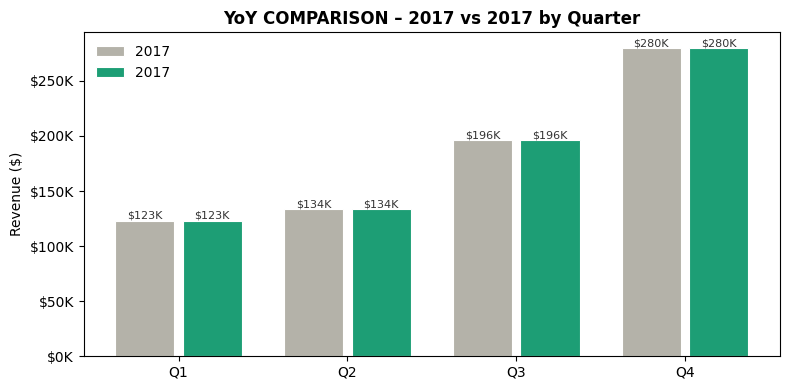

In [24]:

# ── YoY Comparison: 2017 vs 2017 theo quý
years_compare = [2017, 2017]
quarters = [1, 2, 3, 4]
colors_yoy = ['#B4B2A9', '#1D9E75']

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(quarters))
width = 0.35

for j, year in enumerate(years_compare):
    vals = []
    for q in quarters:
        row = quarterly_all = df[(df['Year']==year) & (df['Quarter']==q)]['Sales'].sum()
        vals.append(row)
    offset = (j - 0.5) * (width + 0.05)
    bars = ax.bar(x + offset, vals, width=width, color=colors_yoy[j],
                  label=str(year), edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                f'${v/1000:.0f}K', ha='center', fontsize=8, color='#333')

ax.set_xticks(x)
ax.set_xticklabels([f'Q{q}' for q in quarters])
ax.set_ylabel('Revenue ($)')
ax.set_title('YoY COMPARISON – 2017 vs 2017 by Quarter', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
plt.tight_layout()
plt.show()


## 3.3 MoM Sparklines – Tốc độ thay đổi hàng tháng

### Phương pháp trực quan hóa

Small Multiples / Sparklines

### Mục tiêu

Xem nhanh nhịp tăng trưởng hàng tháng của 3 category. Highlight tháng tốt nhất / xấu nhất.

### Vị trí trong dashboard

→ Cuối màn Trend Analysis


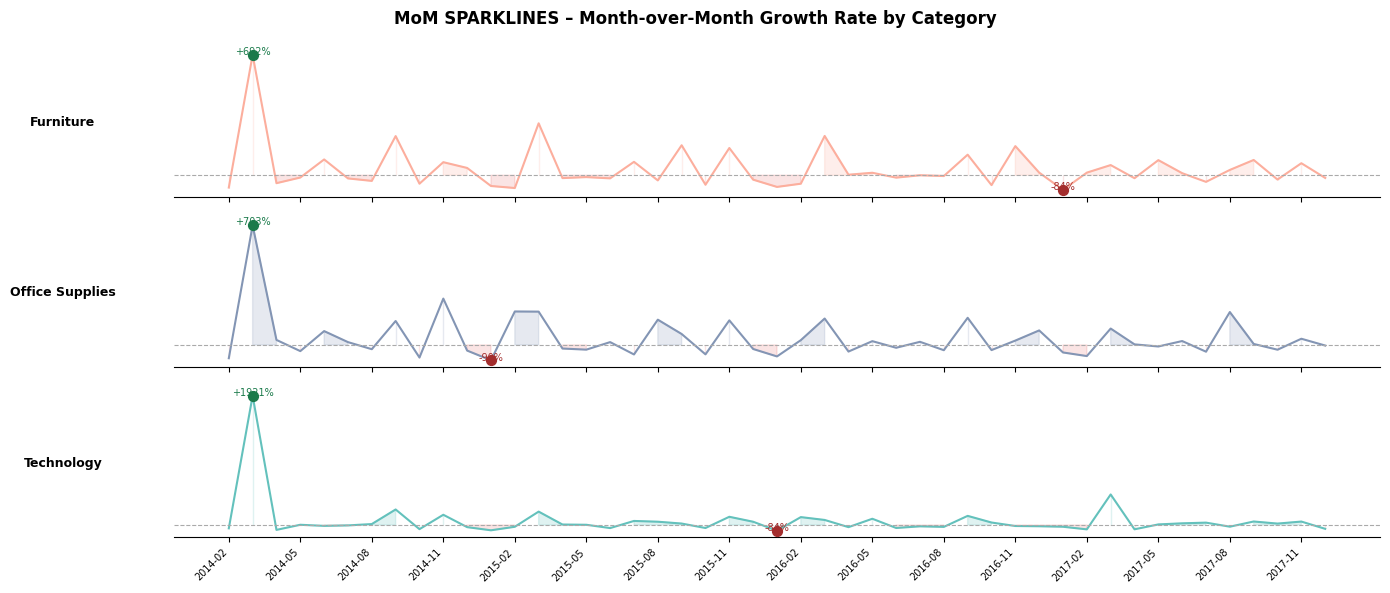

In [25]:

# ── MoM Sparklines by Category
monthly_cat = df.groupby(['YearMonth', 'Category'])['Sales'].sum().reset_index()
monthly_cat = monthly_cat.sort_values('YearMonth')
monthly_cat['MoM'] = monthly_cat.groupby('Category')['Sales'].pct_change() * 100

categories = ['Furniture', 'Office Supplies', 'Technology']
sparkline_colors = ['#FCAE9D', '#8395B4', '#63C1BC']

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for i, (cat, ax) in enumerate(zip(categories, axes)):
    data = monthly_cat[monthly_cat['Category']==cat].dropna()
    x = range(len(data))
    mom = data['MoM'].values
    labels = data['YearMonth'].values

    ax.plot(x, mom, color=sparkline_colors[i], linewidth=1.5)
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--')
    ax.fill_between(x, mom, 0, where=[v>=0 for v in mom],
                    color=sparkline_colors[i], alpha=0.2)
    ax.fill_between(x, mom, 0, where=[v<0 for v in mom],
                    color='#E24B4A', alpha=0.15)

    best_i  = np.argmax(mom)
    worst_i = np.argmin(mom)
    ax.scatter([best_i],  [mom[best_i]],  color='#1a7a4a', zorder=5, s=50)
    ax.scatter([worst_i], [mom[worst_i]], color='#a32d2d', zorder=5, s=50)
    ax.text(best_i,  mom[best_i]+2,  f'+{mom[best_i]:.0f}%', ha='center', fontsize=7, color='#1a7a4a')
    ax.text(worst_i, mom[worst_i]-3, f'{mom[worst_i]:.0f}%', ha='center', fontsize=7, color='#a32d2d')

    ax.set_ylabel(cat, fontsize=9, fontweight='bold', rotation=0, labelpad=80, va='center')
    ax.set_yticks([]); ax.spines[['top','right','left']].set_visible(False)

step = max(1, len(labels)//12)
axes[-1].set_xticks(list(range(0, len(labels), step)))
axes[-1].set_xticklabels(labels[::step], rotation=45, ha='right', fontsize=7)
fig.suptitle('MoM SPARKLINES – Month-over-Month Growth Rate by Category',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
# MÀN 4 – REGION PERFORMANCE: Hiệu suất khu vực
## Câu hỏi: "Which regions will reach their goals — and which need intervention?"
---

## Bố cục màn này

| Vị trí | Biểu đồ                                       |
| ------ | --------------------------------------------- |
| Trái   | Region Comparison Bar có đường Target         |
| Phải   | Top 5 & Bottom 5 States                       |
| Dưới   | Region Pace Chart (% đạt target theo khu vực) |


## 4.1 Region Comparison Bar + Target Line

### Phương pháp trực quan hóa

Horizontal Bar Chart với reference line

### Mục tiêu

Nhìn ngay khu vực nào đạt/chưa đạt mục tiêu doanh thu.
Đường Target dọc là ranh giới rõ ràng.

### Vị trí trong dashboard

→ Bên trái màn Region


C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\806909908.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


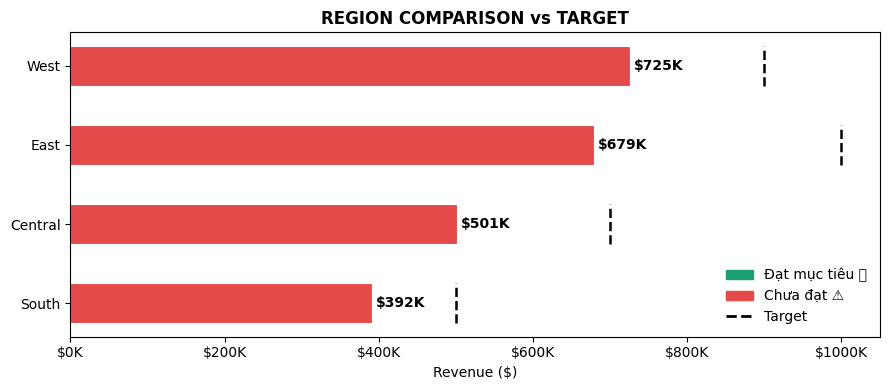

In [26]:

# ── Region Comparison với Target Line
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
region_targets = {'South': 500_000, 'Central': 700_000, 'East': 1_000_000, 'West': 900_000}

fig, ax = plt.subplots(figsize=(9, 4))
regions = region_sales.index.tolist()
vals = region_sales.values
bar_colors = ['#1D9E75' if vals[i] >= region_targets.get(regions[i], 0) else '#E24B4A'
              for i in range(len(regions))]

bars = ax.barh(regions, vals, color=bar_colors, edgecolor='white', linewidth=0.8, height=0.5)

for region, bar in zip(regions, bars):
    target = region_targets.get(region, 0)
    ax.vlines(target, bar.get_y(), bar.get_y()+bar.get_height(),
              color='black', linestyle='--', linewidth=1.8, zorder=5)
    ax.text(vals[regions.index(region)] + 5000, bar.get_y() + bar.get_height()/2,
            f'${vals[regions.index(region)]/1000:.0f}K',
            va='center', fontsize=10, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#1D9E75', label='Đạt mục tiêu ✅'),
    mpatches.Patch(color='#E24B4A', label='Chưa đạt ⚠️'),
    Line2D([0],[0], color='black', linestyle='--', linewidth=2, label='Target'),
]
ax.legend(handles=legend_elements, frameon=False, loc='lower right')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.set_title('REGION COMPARISON vs TARGET', fontsize=12, fontweight='bold')
ax.set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()


## 4.2 Top 5 & Bottom 5 States

### Phương pháp trực quan hóa

Ranked Bar Chart (2 panels: Top / Bottom)

### Mục tiêu

Xác định tiểu bang nào tốt nhất và kém nhất để tập trung nguồn lực.

### Vị trí trong dashboard

→ Bên phải màn Region


C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\658320100.py:26: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


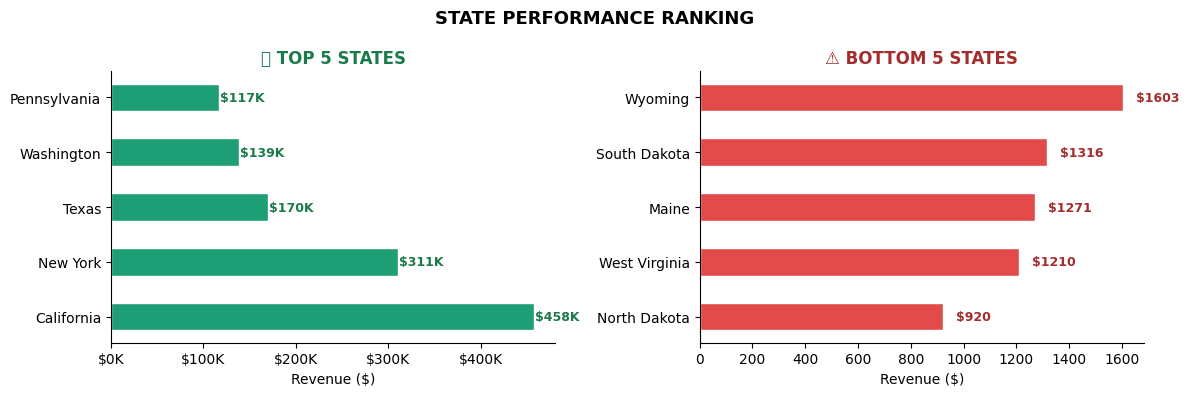

In [27]:

# ── Top 5 & Bottom 5 States
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
top5 = state_sales.head(5)
bot5 = state_sales.tail(5).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Top 5
ax1.barh(top5.index, top5.values, color='#1D9E75', edgecolor='white', height=0.5)
for i, (state, v) in enumerate(zip(top5.index, top5.values)):
    ax1.text(v + 1000, i, f'${v/1000:.0f}K', va='center', fontsize=9, fontweight='bold', color='#1a7a4a')
ax1.set_title('🏆 TOP 5 STATES', fontsize=12, fontweight='bold', color='#1a7a4a')
ax1.set_xlabel('Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax1.spines[['top','right']].set_visible(False)

# Bottom 5
ax2.barh(bot5.index, bot5.values, color='#E24B4A', edgecolor='white', height=0.5)
for i, (state, v) in enumerate(zip(bot5.index, bot5.values)):
    ax2.text(v + 50, i, f'${v:.0f}', va='center', fontsize=9, fontweight='bold', color='#a32d2d')
ax2.set_title('⚠️ BOTTOM 5 STATES', fontsize=12, fontweight='bold', color='#a32d2d')
ax2.set_xlabel('Revenue ($)')
ax2.spines[['top','right']].set_visible(False)

fig.suptitle('STATE PERFORMANCE RANKING', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# MÀN 5 – PROFIT ANALYSIS: Phân tích lợi nhuận
## Câu hỏi: "We're selling more — but are we actually more profitable?"
---

## Bố cục màn này

| Vị trí    | Biểu đồ                                                 |
| --------- | ------------------------------------------------------- |
| Trái      | Profit by Category & Sub-Category (diverging bar)       |
| Phải trên | Profit Margin Trend (% margin theo quý)                 |
| Phải dưới | Profitability Scatter (Sales vs Profit, màu = Category) |


## 5.1 Profit Margin Trend

### Phương pháp trực quan hóa

Line Chart với đường target margin

### Mục tiêu

Xem liệu biên lợi nhuận có đang tăng hay bị bào mòn theo thời gian.
Target margin = 15% là ngưỡng doanh nghiệp đặt ra.

### Vị trí trong dashboard

→ Phải trên màn Profit


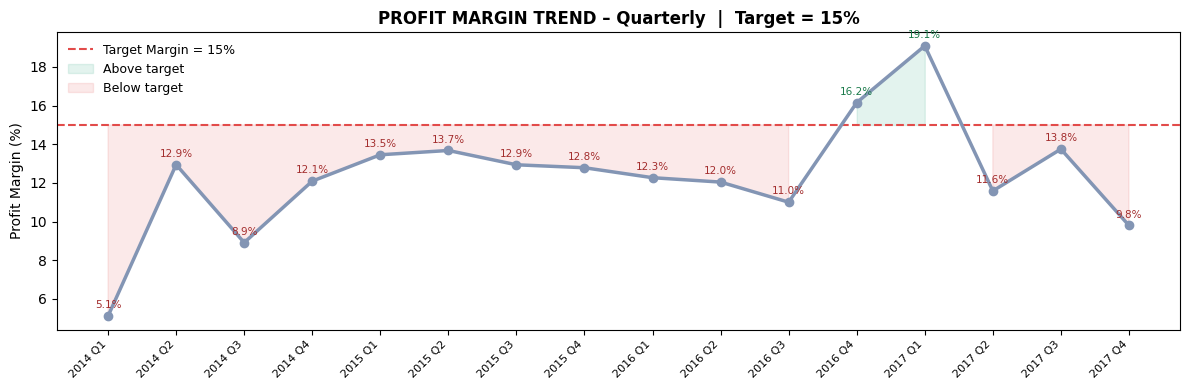

In [28]:

# ── Profit Margin Trend theo quý
quarterly_pnl = df.groupby(['Year', 'Quarter'])[['Sales','Profit']].sum().reset_index()
quarterly_pnl['Margin'] = quarterly_pnl['Profit'] / quarterly_pnl['Sales'] * 100
quarterly_pnl['label'] = quarterly_pnl['Year'].astype(str) + ' Q' + quarterly_pnl['Quarter'].astype(str)
quarterly_pnl = quarterly_pnl.sort_values(['Year','Quarter'])

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(quarterly_pnl))
margin = quarterly_pnl['Margin'].values
labels = quarterly_pnl['label'].values

ax.plot(x, margin, color='#8395B4', linewidth=2.5, marker='o', markersize=6, zorder=3)
ax.axhline(15, color='#E24B4A', linestyle='--', linewidth=1.5, label='Target Margin = 15%')
ax.fill_between(x, margin, 15, where=[v>=15 for v in margin],
                color='#1D9E75', alpha=0.12, label='Above target')
ax.fill_between(x, margin, 15, where=[v<15 for v in margin],
                color='#E24B4A', alpha=0.12, label='Below target')

for xi, v in zip(x, margin):
    ax.text(xi, v+0.4, f'{v:.1f}%', ha='center', fontsize=7.5,
            color='#1a7a4a' if v>=15 else '#a32d2d')

ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Profit Margin (%)')
ax.set_title('PROFIT MARGIN TREND – Quarterly  |  Target = 15%', fontsize=12, fontweight='bold')
ax.legend(frameon=False, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 5.2 Profitability Scatter – Sales vs Profit

### Phương pháp trực quan hóa

Scatter Plot

### Mục tiêu

Nhìn toàn bộ sub-category trên 1 biểu đồ:

- Trục X = doanh thu
- Trục Y = lợi nhuận
- Màu = Category
- Size = số lượng đơn hàng

Sub-category ở góc trái dưới (doanh thu thấp, lãi âm) = vấn đề lớn.

### Vị trí trong dashboard

→ Phải dưới màn Profit


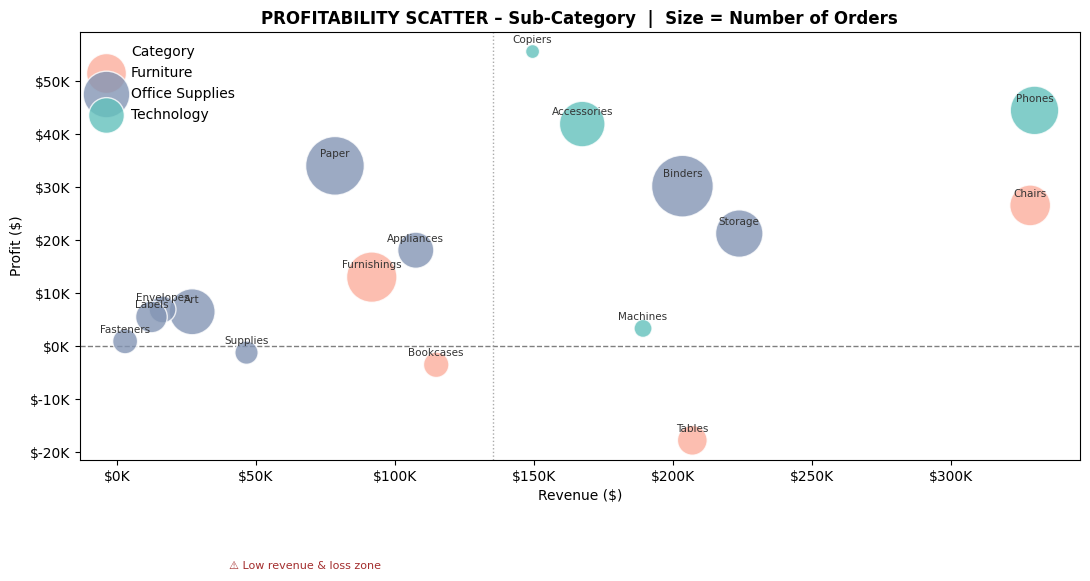

In [29]:

# ── Profitability Scatter: Sub-Category (Sales vs Profit)
subcat = df.groupby(['Sub-Category','Category']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()

cat_colors = {'Furniture':'#FCAE9D', 'Office Supplies':'#8395B4', 'Technology':'#63C1BC'}

fig, ax = plt.subplots(figsize=(11, 6))

for cat, group in subcat.groupby('Category'):
    sc = ax.scatter(group['Sales'], group['Profit'],
                    c=cat_colors[cat], s=group['Orders']*1.5,
                    alpha=0.8, edgecolors='white', linewidth=1, label=cat, zorder=3)

for _, row in subcat.iterrows():
    ax.annotate(row['Sub-Category'],
                (row['Sales'], row['Profit']),
                fontsize=7.5, ha='center', va='bottom', color='#333',
                xytext=(0, 5), textcoords='offset points')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(subcat['Sales'].mean(), color='#AAAAAA', linestyle=':', linewidth=1)

ax.set_xlabel('Revenue ($)'); ax.set_ylabel('Profit ($)')
ax.set_title('PROFITABILITY SCATTER – Sub-Category  |  Size = Number of Orders',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.legend(frameon=False, title='Category', loc='upper left')
ax.add_patch(mpatches.FancyBboxPatch((0, -30000), subcat['Sales'].mean(), -25000,
             boxstyle="round,pad=2000", facecolor='#FCEBEB', edgecolor='#E24B4A',
             linewidth=1, alpha=0.4, zorder=1))
ax.text(subcat['Sales'].mean()*0.3, -42000, '⚠️ Low revenue & loss zone',
        fontsize=8, color='#a32d2d')
plt.tight_layout()
plt.show()


---
# MÀN 6 – COMPARISON & STANDARDIZATION: So sánh & Dự báo
## Câu hỏi: "If current pace continues — will we reach our goals by year end?"
---

## Bố cục màn này

| Vị trí | Biểu đồ                                                                  |
| ------ | ------------------------------------------------------------------------ |
| Top    | Side-by-side Comparison: Actual vs 2 kịch bản (Optimistic / Pessimistic) |
| Giữa   | Variance Analysis Waterfall: Target → Actual, phân tích gap              |
| Dưới   | Growth Index tổng hợp tất cả KPI trên cùng 1 biểu đồ                     |


## 6.1 Variance Analysis – Waterfall Chart

### Phương pháp trực quan hóa

Waterfall Chart

### Mục tiêu

Phân tích tại sao doanh thu thực tế thấp hơn target:

- Bắt đầu từ Target
- Từng yếu tố đóng góp vào gap
- Kết thúc tại Actual

### Vị trí trong dashboard

→ Giữa màn Comparison


C:\Users\ACER\AppData\Local\Temp\ipykernel_9388\1850512753.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


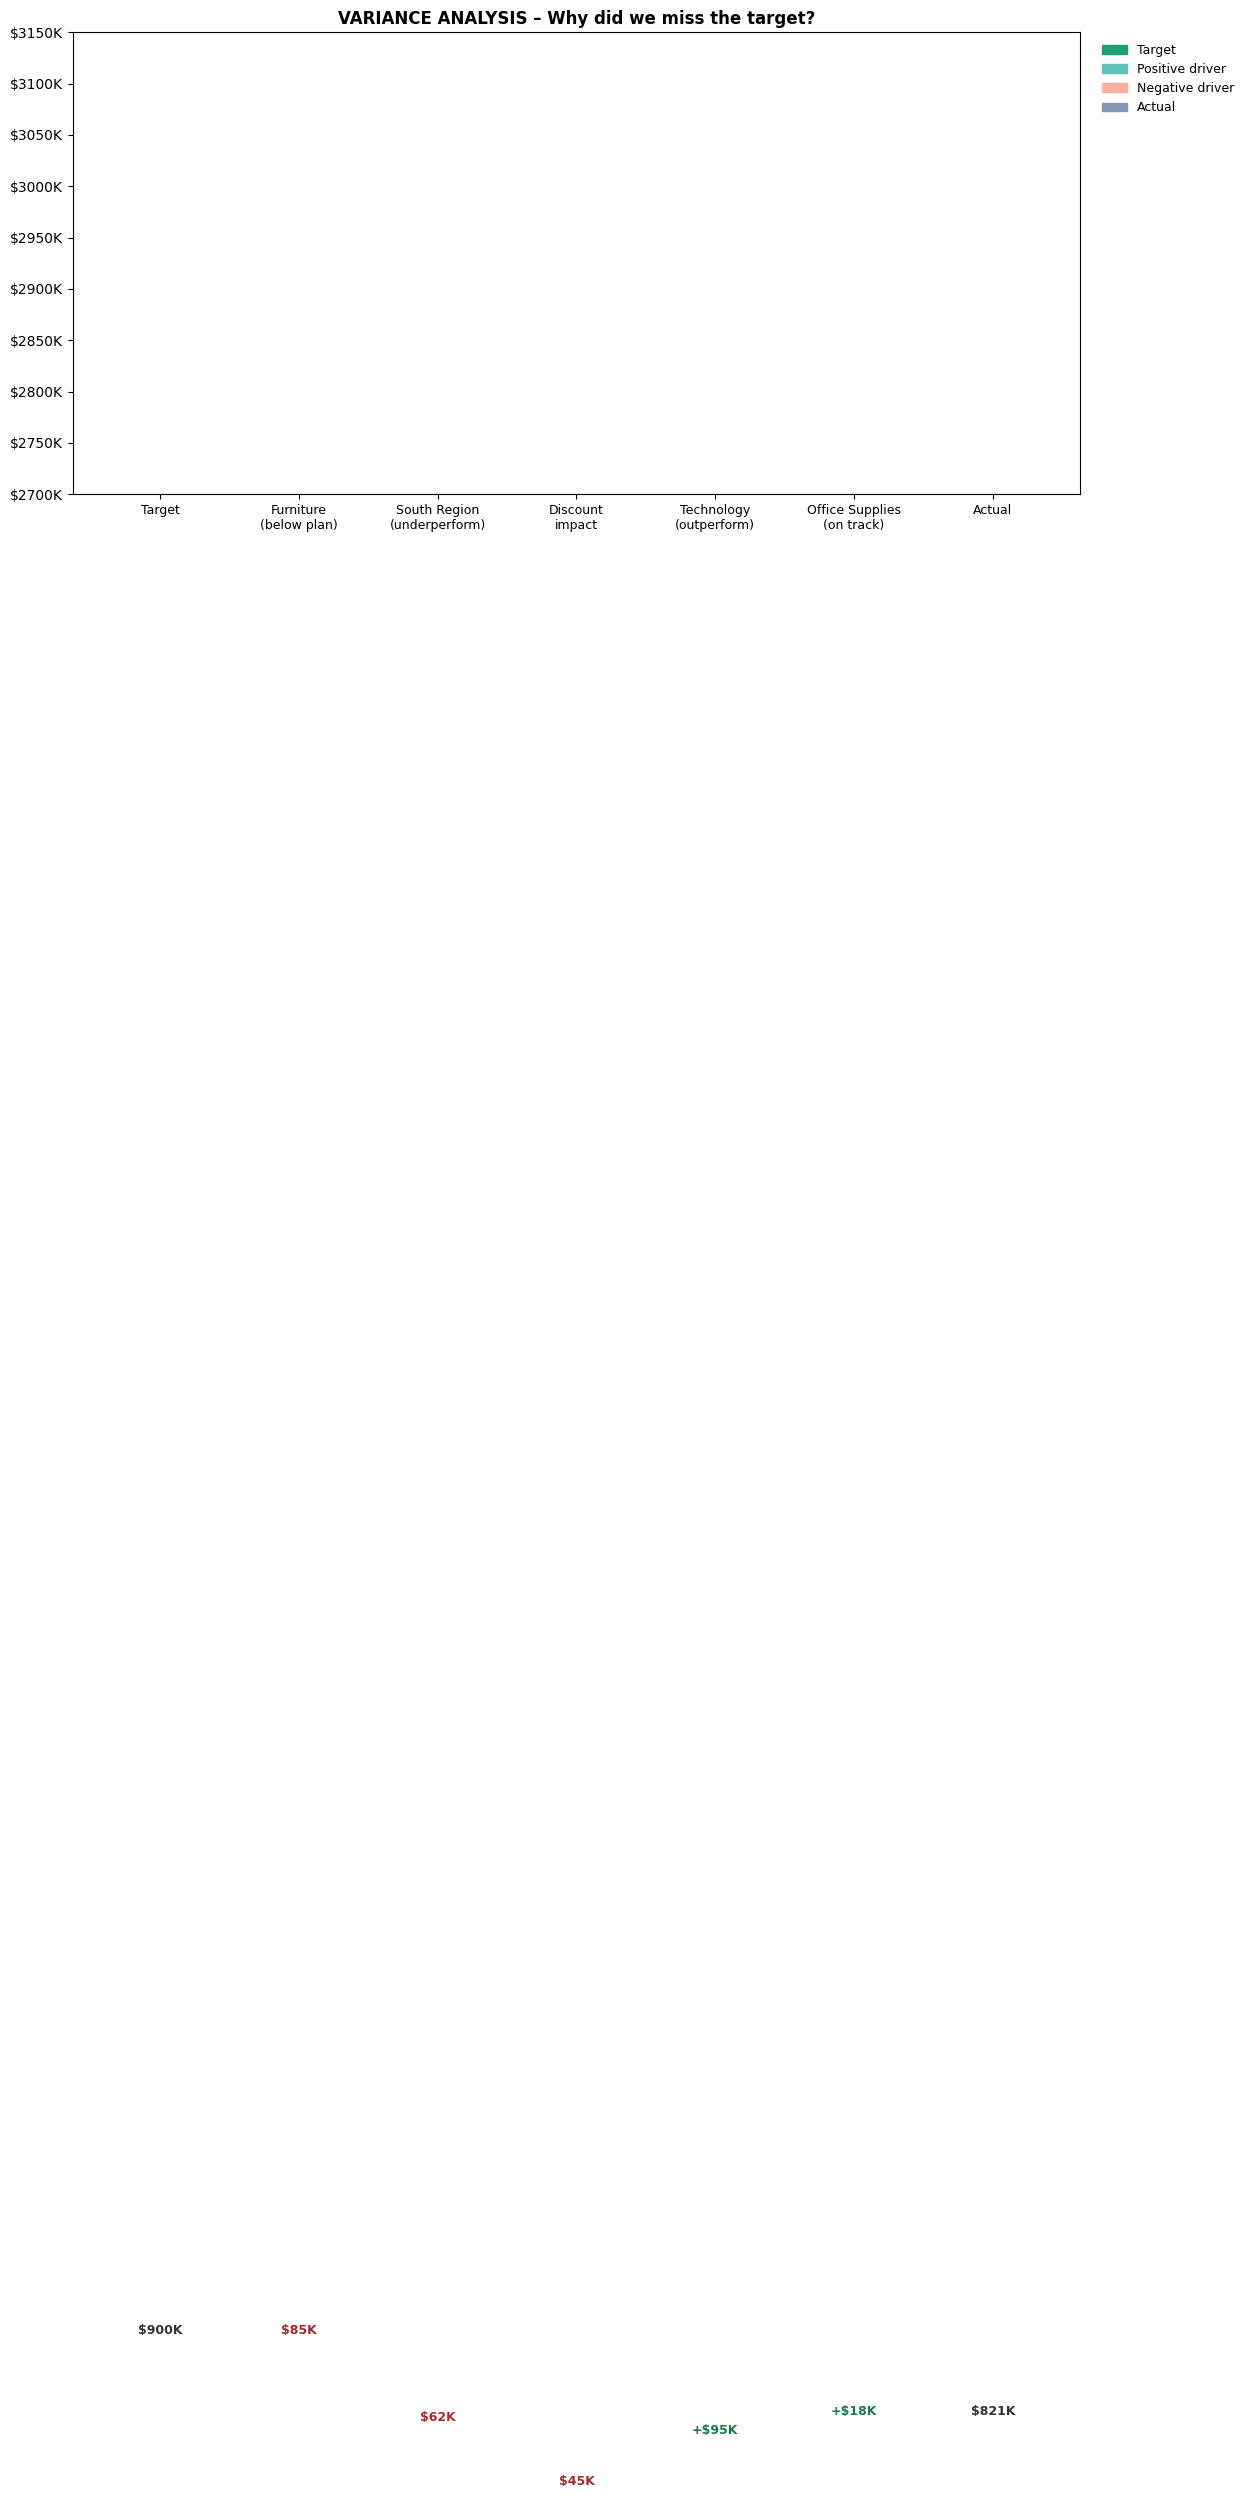

In [30]:
waterfall_labels = ['Target', 'Furniture\n(below plan)', 'South Region\n(underperform)',
                    'Discount\nimpact', 'Technology\n(outperform)', 'Office Supplies\n(on track)', 'Actual']
drivers = [-85000, -62000, -45000, +95000, +18000]
actual_val = target + sum(drivers)

bottoms, heights, colors_wf, values = [], [], [], []

# Target bar
bottoms.append(0); heights.append(target)
colors_wf.append('#1D9E75'); values.append(target)

# Driver bars
running = target
for v in drivers:
    if v >= 0:
        bottoms.append(running); heights.append(v); colors_wf.append('#63C1BC')
    else:
        bottoms.append(running + v); heights.append(abs(v)); colors_wf.append('#FCAE9D')
    values.append(v)
    running += v

# Actual bar
bottoms.append(0); heights.append(actual_val)
colors_wf.append('#8395B4'); values.append(actual_val)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(waterfall_labels))
ax.bar(x, heights, bottom=bottoms, color=colors_wf, edgecolor='white', linewidth=1, width=0.6)

# Labels trên bar
for xi, (b, h, v) in enumerate(zip(bottoms, heights, values)):
    sign = '+' if (v > 0 and xi not in [0, len(values)-1]) else ''
    color = '#333' if xi in [0, len(values)-1] else ('#1a7a4a' if v > 0 else '#a32d2d')
    ax.text(xi, b + h + 8000, f'{sign}${abs(v)/1000:.0f}K',
            ha='center', fontsize=9, fontweight='bold', color=color)

# Connector lines giữa các driver
running = target
for i in range(1, len(waterfall_labels)-1):
    ax.plot([i - 0.3, i + 0.3], [running, running],
            color='#AAAAAA', linewidth=1, zorder=5)
    running += drivers[i-1]

ax.axhline(target, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(waterfall_labels, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax.set_title('VARIANCE ANALYSIS – Why did we miss the target?', fontsize=12, fontweight='bold')
ax.set_ylim(2_700_000, 3_150_000)
legend_elements = [
    mpatches.Patch(color='#1D9E75', label='Target'),
    mpatches.Patch(color='#63C1BC', label='Positive driver'),
    mpatches.Patch(color='#FCAE9D', label='Negative driver'),
    mpatches.Patch(color='#8395B4', label='Actual'),
]
ax.legend(handles=legend_elements, frameon=False, 
          loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()


## 6.2 Scenario Projection – Actual vs Optimistic vs Pessimistic

### Phương pháp trực quan hóa

Line Chart + Shaded Area (Confidence/Scenario Band)

### Mục tiêu

Dự báo doanh thu cuối năm theo 3 kịch bản:

- Pessimistic: tiếp tục đà hiện tại không đổi
- Base: tăng nhẹ theo seasonality lịch sử
- Optimistic: nếu cải thiện được Southern region + discount

### Vị trí trong dashboard

→ Top màn Comparison


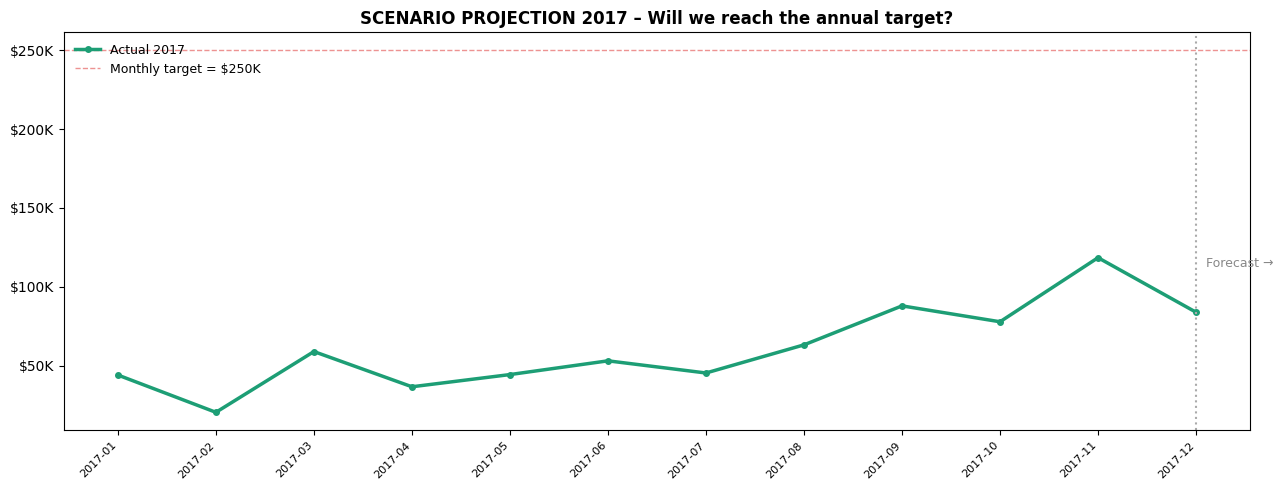

In [31]:

# ── Scenario Projection: 3 kịch bản dự báo cuối năm
monthly_2017 = df[df['Year']==2017].groupby('YearMonth')['Sales'].sum().reset_index()
monthly_2017 = monthly_2017.sort_values('YearMonth')

historical_monthly = df[df['Year'] < 2017].groupby(
    df[df['Year']<2017]['Order Date'].dt.month)['Sales'].mean().reset_index()
historical_monthly.columns = ['Month', 'avg_sales']

months_2017 = monthly_2017['YearMonth'].tolist()
actual_vals  = monthly_2017['Sales'].tolist()
last_actual  = actual_vals[-1]

future_months = [f'2017-{m:02d}' for m in range(len(months_2017)+1, 13)]
if future_months:
    growth_base = 1.05
    base_proj    = [last_actual * (growth_base**i) for i in range(1, len(future_months)+1)]
    optimistic   = [v * 1.12 for v in base_proj]
    pessimistic  = [v * 0.92 for v in base_proj]
else:
    future_months, base_proj, optimistic, pessimistic = [], [], [], []

all_months = months_2017 + future_months
actual_full = actual_vals + [None]*len(future_months)
base_full   = [None]*(len(months_2017)-1) + [actual_vals[-1]] + base_proj
opt_full    = [None]*(len(months_2017)-1) + [actual_vals[-1]] + optimistic
pess_full   = [None]*(len(months_2017)-1) + [actual_vals[-1]] + pessimistic

x = range(len(all_months))
split = len(months_2017) - 1

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(list(x)[:len(actual_vals)], actual_vals, color='#1D9E75', linewidth=2.5,
        label='Actual 2017', marker='o', markersize=4)
ax.axvline(split, color='#AAAAAA', linestyle=':', linewidth=1.5)
ax.text(split+0.1, max(actual_vals)*0.95, 'Forecast →', fontsize=9, color='#888')

if future_months:
    fx = list(range(split, len(all_months)))
    ax.plot(fx, [actual_vals[-1]]+base_proj, color='#8395B4', linewidth=2, linestyle='--', label='Base scenario')
    ax.plot(fx, [actual_vals[-1]]+optimistic, color='#63C1BC', linewidth=2, linestyle='-.', label='Optimistic')
    ax.plot(fx, [actual_vals[-1]]+pessimistic, color='#FCAE9D', linewidth=2, linestyle=':', label='Pessimistic')
    ax.fill_between(fx, [actual_vals[-1]]+pessimistic, [actual_vals[-1]]+optimistic,
                    color='#8395B4', alpha=0.08)

ax.axhline(sales_target/12, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Monthly target = ${sales_target/12/1000:.0f}K')

step = max(1, len(all_months)//10)
ax.set_xticks(list(range(0, len(all_months), step)))
ax.set_xticklabels(all_months[::step], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.set_title('SCENARIO PROJECTION 2017 – Will we reach the annual target?',
             fontsize=12, fontweight='bold')
ax.legend(frameon=False, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


---

# Dashboard Layout – 6 Màn Hoàn Chỉnh

```text
═══════════════════════════════════════════════════════════
       EXECUTIVE KPI DASHBOARD – ARE WE GOING TO REACH OUR GOALS?
═══════════════════════════════════════════════════════════

MÀN 1 – OVERVIEW
┌─────────────────────────────────────────────────────────┐
│  [Bullet Insights – 3 dòng: ✅ Going Well / ⚠️ Watch / 🔴 Action] │
│  [KPI Card: Revenue] [KPI Card: Profit] [Orders] [Customers]  │
│  [────────── Pace Chart (tiến độ tổng hợp) ──────────]  │
│  [Region Bar + Target Line]  [Growth Index Chart]       │
│  [────── Revenue Trend Line Chart (multi-category) ─────]│
└─────────────────────────────────────────────────────────┘

MÀN 2 – KPI PROGRESS
┌─────────────────────────────────────────────────────────┐
│  [Overall Gauge 68%]  [Pace Chart tổng hợp]             │
│  [Bullet Charts: Revenue / Profit / Orders / Customers] │
│  [Donut: Furniture 58%] [Office Supplies 71%] [Tech 84%]│
└─────────────────────────────────────────────────────────┘

MÀN 3 – TREND ANALYSIS
┌─────────────────────────────────────────────────────────┐
│  [Revenue Multi-line Trend – 3 categories theo quý]     │
│  [YoY Growth Rate Trend]  [YoY Comparison 2017 vs 2017] │
│  [MoM Sparklines – Furniture / Office Supplies / Tech]  │
└─────────────────────────────────────────────────────────┘

MÀN 4 – REGION PERFORMANCE
┌─────────────────────────────────────────────────────────┐
│  [Region Bar + Target Line (West/East/Central/South)]   │
│  [Top 5 States 🏆]           [Bottom 5 States ⚠️]       │
│  [Region Pace Chart – % đạt target từng vùng]           │
└─────────────────────────────────────────────────────────┘

MÀN 5 – PROFIT ANALYSIS
┌─────────────────────────────────────────────────────────┐
│  [Profit by Sub-Category – Diverging Bar]               │
│  [Profit Margin Trend – Target = 15%]                   │
│  [Profitability Scatter – Sales vs Profit, màu=Category]│
└─────────────────────────────────────────────────────────┘

MÀN 6 – COMPARISON & STANDARDIZATION
┌─────────────────────────────────────────────────────────┐
│  [Scenario Projection: Actual vs Base vs Opt vs Pess]   │
│  [Waterfall Variance: Target → drivers → Actual]        │
│  [Growth Index: tất cả KPI chuẩn hóa 100]              │
└─────────────────────────────────────────────────────────┘
```


# 11. Cách thuyết trình với giảng viên

## Mở đầu

“Dashboard được xây dựng dựa trên Chapter 7 của The Big Book of Dashboards.”

## Trình bày tư duy

- Theo dõi tiến độ KPI
- Dùng Pace Chart
- Chuẩn hóa dữ liệu bằng Index
- Thiết kế executive dashboard

## Giải thích trực quan hóa

- KPI Cards → tổng quan
- Pace Chart → tiến độ KPI
- Line Chart → xu hướng
- Bar Chart → so sánh

## Kết luận

Dashboard hỗ trợ lãnh đạo:

- Ra quyết định nhanh
- Theo dõi KPI
- Phát hiện vấn đề sớm
